In [2]:
import pandas as pd
df = pd.read_csv("/content/fake reviews dataset.csv")

In [3]:
df.head(4)

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."


In [4]:
df = df.rename(columns={'text_': 'text'})

In [5]:
print(df['label'].unique())
print(df.columns)
print(df[['label']].head(10))

['CG' 'OR']
Index(['category', 'rating', 'label', 'text'], dtype='object')
  label
0    CG
1    CG
2    CG
3    CG
4    CG
5    CG
6    CG
7    CG
8    CG
9    CG


In [6]:
df['label'] = df['label'].map({'CG': 1, 'OR': 0})

In [7]:
df.head(4)

,category,rating,label,text
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i..."


In [ ]:
# Check missing values
print(df.isnull().sum())

# Drop rows where 'text' is null or empty
df = df.dropna(subset=['text'])
df = df[df['text'].str.strip() != ""]

# For category/rating:
# - If very few missing, drop them
# - If many missing, you can impute (fillna with "unknown" or mean)

df['category'] = df['category'].fillna("unknown")
df['rating'] = df['rating'].fillna(df['rating'].mean())  # or median

category    0
rating      0
label       0
text        0
dtype: int64


In [ ]:
df.head(4)

,category,rating,label,text
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i..."


In [8]:
from sklearn.preprocessing import LabelEncoder
# create encoder
encoder = LabelEncoder()

# fit and transform
df['category_encoded'] = encoder.fit_transform(df['category'])

# check mapping
mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
print("Category: Encoded mapping-", mapping)

Category: Encoded mapping- {'Books_5': np.int64(0), 'Clothing_Shoes_and_Jewelry_5': np.int64(1), 'Electronics_5': np.int64(2), 'Home_and_Kitchen_5': np.int64(3), 'Kindle_Store_5': np.int64(4), 'Movies_and_TV_5': np.int64(5), 'Pet_Supplies_5': np.int64(6), 'Sports_and_Outdoors_5': np.int64(7), 'Tools_and_Home_Improvement_5': np.int64(8), 'Toys_and_Games_5': np.int64(9)}


In [ ]:
import re, string

def clean_text(text):
    text = str(text).lower()    # convert to lowercase
    text = re.sub(r'\d+', '', text)  #remove numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  #remove punctuations
    text = re.sub(r'\s+', ' ', text).strip()  #remove extra spaces
    return text
df['clean_text'] = df['text'].apply(clean_text)

In [ ]:
df.head(4)

,category,rating,label,text,category_encoded,clean_text
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfor...",3,love this well made sturdy and very comfortabl...
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I...",3,love it a great upgrade from the original ive ...
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...,3,this pillow saved my back i love the look and ...
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i...",3,missing information on how to use it but it is...


### Feature Engineering(Metadata)

In [ ]:
import numpy as np
from textblob import TextBlob

# Length features
df['review_length_words'] = df['clean_text'].apply(lambda x: len(x.split()))
df['review_length_chars'] = df['clean_text'].apply(len)
df['avg_word_length'] = df['clean_text'].apply(
    lambda x: np.mean([len(w) for w in x.split()]) if len(x.split()) > 0 else 0
)

# Style features (use text_ since your column is named that)
df['num_exclamations'] = df['text'].apply(lambda x: str(x).count('!'))
df['num_uppercase'] = df['text'].apply(lambda x: sum(1 for w in str(x).split() if w.isupper()))

# Sentiment feature
df['sentiment_score'] = df['clean_text'].apply(lambda x: TextBlob(x).sentiment.polarity)
#-1 for negative and +1 for positive

# Rating-based feature
df['extreme_rating'] = df['rating'].apply(lambda x: 1 if (x <= 2 or x >= 4) else 0)

#duplicate count
df['duplicate_count'] = df.groupby('text')['text'].transform('count') #Counts how many times the exact same review text appears in the dataset.

In [ ]:
df.head(4)

,category,rating,label,text,category_encoded,clean_text,review_length_words,review_length_chars,avg_word_length,num_exclamations,num_uppercase,sentiment_score,extreme_rating,duplicate_count
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfor...",3,love this well made sturdy and very comfortabl...,12,68,4.750000,2,1,0.442500,1,1
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I...",3,love it a great upgrade from the original ive ...,16,76,3.812500,0,0,0.558333,1,1
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...,3,this pillow saved my back i love the look and ...,14,65,3.714286,0,1,0.250000,1,1
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i...",3,missing information on how to use it but it is...,17,78,3.647059,1,1,0.300000,1,1


In [ ]:
print(df.isnull().sum())
print((df['text'].str.strip() == "").sum())
print(df.duplicated(subset=['text']).sum())
print(df[['review_length_words','review_length_chars','avg_word_length']].describe())

category               0
rating                 0
label                  0
text                   0
category_encoded       0
clean_text             0
review_length_words    0
review_length_chars    0
avg_word_length        0
num_exclamations       0
num_uppercase          0
sentiment_score        0
extreme_rating         0
duplicate_count        0
dtype: int64
0
20
       review_length_words  review_length_chars  avg_word_length
count         40432.000000         40432.000000     40432.000000
mean             66.876162           337.466215         4.064012
std              68.917996           354.737859         0.576978
min               0.000000             0.000000         0.000000
25%              20.000000           102.000000         3.734878
50%              38.000000           191.000000         4.000000
75%              84.000000           422.000000         4.318182
max             369.000000          2530.000000        32.600000


In [ ]:
# Ensure labels are always int32
y = df['label'].astype(np.int32)   # RF notebook

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
# df = pd.read_csv("your_dataset.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
X_train_text, X_test_text, y_train, y_test, X_train_meta, X_test_meta = train_test_split(
    X_text, y, X_meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))


Train size: 32345
Test size: 8087


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. TF-IDF for text
# -------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# -------------------------
# 2. Combine TF-IDF + metadata
# -------------------------
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_test_final  = hstack([X_test_tfidf, csr_matrix(X_test_meta)])

print("RF Train shape:", X_train_final.shape)
print("RF Test shape:", X_test_final.shape)

# -------------------------
# 3. Train RF
# -------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train_final.toarray(), y_train)

print("OOB Score:", rf.oob_score_)

RF Train shape: (32345, 5010)
RF Test shape: (8087, 5010)
OOB Score: 0.9116710465296027


Training Accuracy: 1.0
Test Accuracy: 0.9204896747866947

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4044
           1       0.94      0.90      0.92      4043

    accuracy                           0.92      8087
   macro avg       0.92      0.92      0.92      8087
weighted avg       0.92      0.92      0.92      8087

[[3810  234]
 [ 409 3634]]
Sum of confusion matrix: 8087


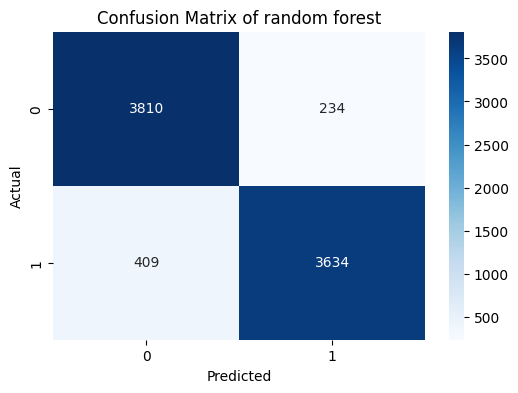

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = rf.predict(X_train_final.toarray())
y_test_pred  = rf.predict(X_test_final.toarray())

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Classification Report (Test Data)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])
print(cm)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of random forest")
plt.show()

In [ ]:
# Probability that each review is fake (label=1)
y_proba = rf.predict_proba(X_test_final)[:, 1]
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.1, 1.0, 0.01)  # from 0.1 to 1.0
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)  # apply threshold
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (max F1-score): {best_threshold:.2f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall   : {recalls[best_idx]:.4f}")
print(f"F1-score : {f1s[best_idx]:.4f}")


Best Threshold (max F1-score): 0.48
Precision: 0.9277
Recall   : 0.9204
F1-score : 0.9240


In [ ]:
# Apply the best threshold
y_pred_best_thresh = (y_proba >= best_threshold).astype(int)

# Count predicted fake reviews
fake_count = np.sum(y_pred_best_thresh == 1)

# Print the result
print(f"Predicted fake reviews (threshold={best_threshold:.2f}): {fake_count}")
# Count of actual fake reviews in test set
actual_fake_count = np.sum(y_test == 1)
print("Count of actual fake reviews in test set:", actual_fake_count)

Predicted fake reviews (threshold=0.48): 4011
Count of actual fake reviews in test set: 4043


In [ ]:
print("y_test shape:", y_test.shape)
print("Unique labels in y_test:", np.unique(y_test, return_counts=True))


y_test shape: (8087,)
Unique labels in y_test: (array([0, 1], dtype=int32), array([4044, 4043]))


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
# df = pd.read_csv("your_dataset.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
X_train_text, X_test_text, y_train, y_test, X_train_meta, X_test_meta = train_test_split(
    X_text, y, X_meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))


Train size: 32345
Test size: 8087


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. TF-IDF for text
# -------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# -------------------------
# 2. Combine TF-IDF + metadata
# -------------------------
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_test_final  = hstack([X_test_tfidf, csr_matrix(X_test_meta)])

print("RF Train shape:", X_train_final.shape)
print("RF Test shape:", X_test_final.shape)

# -------------------------
# 3. Train RF
# -------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features='sqrt',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train_final.toarray(), y_train)

print("OOB Score:", rf.oob_score_)

RF Train shape: (32345, 5010)
RF Test shape: (8087, 5010)
OOB Score: 0.9116710465296027


Training Accuracy: 1.0
Test Accuracy: 0.9204896747866947

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4044
           1       0.94      0.90      0.92      4043

    accuracy                           0.92      8087
   macro avg       0.92      0.92      0.92      8087
weighted avg       0.92      0.92      0.92      8087

[[3810  234]
 [ 409 3634]]
Sum of confusion matrix: 8087


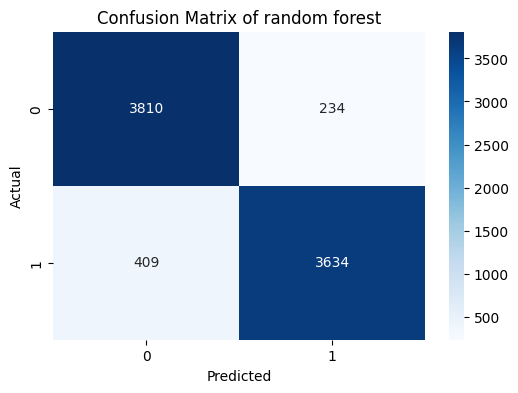

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = rf.predict(X_train_final.toarray())
y_test_pred  = rf.predict(X_test_final.toarray())

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Classification Report (Test Data)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])
print(cm)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of random forest")
plt.show()

In [ ]:
# Probability that each review is fake (label=1)
y_proba = rf.predict_proba(X_test_final)[:, 1]
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.1, 1.0, 0.01)  # from 0.1 to 1.0
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)  # apply threshold
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (max F1-score): {best_threshold:.2f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall   : {recalls[best_idx]:.4f}")
print(f"F1-score : {f1s[best_idx]:.4f}")


Best Threshold (max F1-score): 0.48
Precision: 0.9277
Recall   : 0.9204
F1-score : 0.9240


In [ ]:
# Apply the best threshold
y_pred_best_thresh = (y_proba >= best_threshold).astype(int)

# Count predicted fake reviews
fake_count = np.sum(y_pred_best_thresh == 1)

# Print the result
print(f"Predicted fake reviews (threshold={best_threshold:.2f}): {fake_count}")
# Count of actual fake reviews in test set
actual_fake_count = np.sum(y_test == 1)
print("Count of actual fake reviews in test set:", actual_fake_count)

Predicted fake reviews (threshold=0.48): 4011
Count of actual fake reviews in test set: 4043


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
# df = pd.read_csv("your_dataset.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
X_train_text, X_test_text, y_train, y_test, X_train_meta, X_test_meta = train_test_split(
    X_text, y, X_meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))


Train size: 32345
Test size: 8087


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. TF-IDF for text
# -------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# -------------------------
# 2. Combine TF-IDF + metadata
# -------------------------
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_test_final  = hstack([X_test_tfidf, csr_matrix(X_test_meta)])

print("RF Train shape:", X_train_final.shape)
print("RF Test shape:", X_test_final.shape)

# -------------------------
# 3. Train RF
# -------------------------
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='log2',
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train_final.toarray(), y_train)

print("OOB Score:", rf.oob_score_)

RF Train shape: (32345, 5010)
RF Test shape: (8087, 5010)
OOB Score: 0.8748801978667491


Training Accuracy: 0.8994898747874478
Test Accuracy: 0.8879683442562136

Classification Report (Test Data):
              precision    recall  f1-score   support

           0       0.86      0.93      0.89      4044
           1       0.92      0.85      0.88      4043

    accuracy                           0.89      8087
   macro avg       0.89      0.89      0.89      8087
weighted avg       0.89      0.89      0.89      8087

[[3746  298]
 [ 608 3435]]
Sum of confusion matrix: 8087


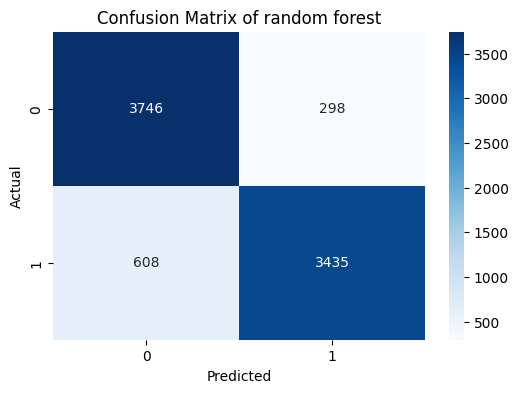

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = rf.predict(X_train_final.toarray())
y_test_pred  = rf.predict(X_test_final.toarray())

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Classification Report (Test Data)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])
print(cm)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of random forest")
plt.show()

In [ ]:
# Probability that each review is fake (label=1)
y_proba = rf.predict_proba(X_test_final)[:, 1]
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.1, 1.0, 0.01)  # from 0.1 to 1.0
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)  # apply threshold
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (max F1-score): {best_threshold:.2f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall   : {recalls[best_idx]:.4f}")
print(f"F1-score : {f1s[best_idx]:.4f}")


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.p

Best Threshold (max F1-score): 0.49
Precision: 0.8834
Recall   : 0.8922
F1-score : 0.8878


In [ ]:
# Apply the best threshold
y_pred_best_thresh = (y_proba >= best_threshold).astype(int)

# Count predicted fake reviews
fake_count = np.sum(y_pred_best_thresh == 1)

# Print the result
print(f"Predicted fake reviews (threshold={best_threshold:.2f}): {fake_count}")
# Count of actual fake reviews in test set
actual_fake_count = np.sum(y_test == 1)
print("Count of actual fake reviews in test set:", actual_fake_count)

Predicted fake reviews (threshold=0.49): 4083
Count of actual fake reviews in test set: 4043


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# Load your dataset
# df = pd.read_csv("your_dataset.csv")

# Labels (force int32 for TensorFlow compatibility)
y = df['label'].astype(np.int32)

# Text (for CNN) and metadata (for RF)
X_text = df['clean_text'].values
meta_features = [
    'category_encoded', 'rating',
    'review_length_words', 'review_length_chars',
    'avg_word_length', 'num_exclamations',
    'num_uppercase', 'sentiment_score',
    'extreme_rating', 'duplicate_count'
]
X_meta = df[meta_features].values

# Single train/test split shared by RF and CNN
X_train_text, X_test_text, y_train, y_test, X_train_meta, X_test_meta = train_test_split(
    X_text, y, X_meta,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", len(X_train_text))
print("Test size:", len(X_test_text))

Train size: 32345
Test size: 8087


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse import hstack, csr_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# -------------------------
# 1. TF-IDF for text
# -------------------------
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

# -------------------------
# 2. Combine TF-IDF + metadata
# -------------------------
X_train_final = hstack([X_train_tfidf, csr_matrix(X_train_meta)])
X_test_final  = hstack([X_test_tfidf, csr_matrix(X_test_meta)])

print("RF Train shape:", X_train_final.shape)
print("RF Test shape:", X_test_final.shape)

# -------------------------
# 3. Train RF
# -------------------------
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=0.5,
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
    oob_score=True
)
rf.fit(X_train_final.toarray(), y_train)
print("OOB Score:", rf.oob_score_)

RF Train shape: (32345, 5010)
RF Test shape: (8087, 5010)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_pred = rf.predict(X_train_final.toarray())
y_test_pred  = rf.predict(X_test_final.toarray())

# Accuracy
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy:", accuracy_score(y_test, y_test_pred))

# Classification Report (Test Data)
print("\nClassification Report (Test Data):")
print(classification_report(y_test, y_test_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred, labels=[0,1])
print(cm)
print("Sum of confusion matrix:", cm.sum())
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of random forest")
plt.show()

In [ ]:
# Probability that each review is fake (label=1)
y_proba = rf.predict_proba(X_test_final)[:, 1]
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

thresholds = np.arange(0.1, 1.0, 0.01)  # from 0.1 to 1.0
precisions, recalls, f1s = [], [], []

for t in thresholds:
    y_pred_thresh = (y_proba >= t).astype(int)  # apply threshold
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1s.append(f1_score(y_test, y_pred_thresh))
best_idx = np.argmax(f1s)
best_threshold = thresholds[best_idx]

print(f"Best Threshold (max F1-score): {best_threshold:.2f}")
print(f"Precision: {precisions[best_idx]:.4f}")
print(f"Recall   : {recalls[best_idx]:.4f}")
print(f"F1-score : {f1s[best_idx]:.4f}")

In [ ]:
# Apply the best threshold
y_pred_best_thresh = (y_proba >= best_threshold).astype(int)

# Count predicted fake reviews
fake_count = np.sum(y_pred_best_thresh == 1)

# Print the result
print(f"Predicted fake reviews (threshold={best_threshold:.2f}): {fake_count}")
# Count of actual fake reviews in test set
actual_fake_count = np.sum(y_test == 1)
print("Count of actual fake reviews in test set:", actual_fake_count)